# EDA: продажи Поступашки

Анализ реальных данных о продажах (`base.xlsx`, 795 строк, 04.08–10.09.2026) для Задачи 1 кейса — разобраться, что происходило с продажами, прежде чем переходить к маркетинговой архитектуре.

**Как читать этот ноутбук:** раздел 8 отдельно разделяет то, что мы **знаем** (факт), что **оцениваем** (гипотеза/модель) и что **пока узнать нельзя**.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

## 1. Загрузка данных

In [2]:
df = pd.read_excel('base.xlsx')
df['Время'] = pd.to_datetime(df['Время'])
df['Дата'] = df['Время'].dt.date

print(f"Строк: {len(df)} | Период: {df['Дата'].min()} — {df['Дата'].max()} | "
      f"Уникальных студентов: {df['Номер студента'].nunique()}")
display(df.head())

Строк: 795 | Период: 2026-08-04 — 2026-09-10 | Уникальных студентов: 606


,Номер студента,Сумма,Курс,Время,Дата
0,437,8950.0,ML про,2026-08-04 09:08:31,2026-08-04
1,437,7890.0,Аналитика старт,2026-08-04 09:35:00,2026-08-04
2,443,8475.0,Линейная алгебра,2026-08-04 10:14:38,2026-08-04
3,443,8475.0,Мат анализ,2026-08-04 10:14:38,2026-08-04
4,430,8950.0,К ВУЗу,2026-08-04 13:38:06,2026-08-04


## 2. Что считаем заказом

Строка в таблице — это позиция в чеке, а не обязательно отдельная покупка. Решение: **новый заказ начинается, если студент не покупал ничего больше часа**. Это ловит и мгновенные пакеты (несколько курсов одной секундой), и покупки в рамках одной сессии с разницей в пару минут.

Час — наше допущение, не факт из данных. Ниже видно, зачем оно нужно: при строгом совпадении секунды часть явно единых сессий покупок разъезжается на разные заказы.

In [3]:
df = df.sort_values(['Номер студента', 'Время']).reset_index(drop=True)
df['time_diff'] = df.groupby('Номер студента')['Время'].diff()
df['is_new_order'] = df['time_diff'].isnull() | (df['time_diff'] > pd.Timedelta(hours=1))
df['order_id'] = df['is_new_order'].cumsum()

n_orders_1h = df['order_id'].nunique()
n_orders_strict = df.groupby(['Номер студента', 'Время']).ngroups

print(f"Заказов при окне 1 час: {n_orders_1h}")
print(f"Заказов при строгом совпадении секунды: {n_orders_strict} (разница {n_orders_strict - n_orders_1h} — "
      f"это сессии из пары покупок с разницей в пару минут, которые строгое правило считало бы разными заказами)")

Заказов при окне 1 час: 627
Заказов при строгом совпадении секунды: 628 (разница 1 — это сессии из пары покупок с разницей в пару минут, которые строгое правило считало бы разными заказами)


## 3. Пакеты (бандлы) и структура заказа

In [4]:
orders_df = df.groupby('order_id').agg(
    student_id=('Номер студента', 'first'),
    order_time=('Время', 'min'),
    total_amount=('Сумма', 'sum'),
    courses=('Курс', lambda x: tuple(sorted(x))),
    items_count=('Курс', 'count'),
).reset_index()

bundle_share = (orders_df['items_count'] > 1).mean()
print(f"Заказов с несколькими курсами (бандлы): {(orders_df['items_count'] > 1).sum()} из {len(orders_df)} ({bundle_share:.0%})")
display(orders_df[orders_df['items_count'] > 1].head(5))

Заказов с несколькими курсами (бандлы): 154 из 627 (25%)


,order_id,student_id,order_time,total_amount,courses,items_count
7,8,8,2026-08-08 16:25:39,8990.0,"(АВ тестам, Алгоритмы)",2
15,16,16,2026-08-10 16:56:42,9900.0,"(ML старт, Алгоритмы старт)",2
18,19,19,2026-08-09 11:01:50,9900.0,"(Алгоритмы старт, Аналитика старт)",2
19,20,20,2026-09-06 11:07:00,14950.0,"(Аналитика про, Аналитика старт)",2
20,21,21,2026-08-10 16:29:36,9900.0,"(Алгоритмы старт, Аналитика старт)",2


In [5]:
solo = df.groupby(['Номер студента', 'Время']).filter(lambda g: len(g) == 1)
solo_median = solo.groupby('Курс')['Сумма'].median()

example = orders_df.loc[orders_df['courses'] == ('Алгоритмы старт', 'ML старт'), 'total_amount']
if len(example):
    solo_sum = solo_median.get('ML старт', float('nan')) + solo_median.get('Алгоритмы старт', float('nan'))
    print(f"Пример: 'ML старт' + 'Алгоритмы старт' поодиночке стоили бы медианно {solo_sum:,.0f} ₽, "
          f"а как пакет продавались за {example.min():,.0f}–{example.max():,.0f} ₽ — "
          f"это реальная скидка на пакет, а не совпадение по времени.")

## 4. Продажи по курсам

Считаем на уровне позиции (строки). Оговорка: сумма по позиции внутри бандла — это часть цены пакета, а не независимая цена курса, поэтому `total_revenue` ниже не равно "сколько денег принёс этот курс сам по себе".

In [6]:
course_stats = df.groupby('Курс').agg(
    sales_count=('Сумма', 'count'),
    total_revenue=('Сумма', 'sum'),
).sort_values('sales_count', ascending=False)

display(course_stats)

,sales_count,total_revenue
Курс,,
Аналитика про,93,740941.50
AI агенты,91,711673.00
Аналитика старт,91,641616.50
ML про,90,715110.00
Алгоритмы старт,88,529851.68
ML старт,80,523278.33
Backend про,55,438342.50
Backend старт,39,263396.66
Алгоритмы про,35,268409.00


## 5. Периоды активности

Вместо разбора отдельных "пиковых дней" разложим весь период на 6 непрерывных отрезков — так видно и всплески, и фон между ними. У каждого отрезка — метка уверенности: **факт** (подтверждено самими данными), **гипотеза** (правдоподобное объяснение по паттерну, без внешнего подтверждения) или **неизвестно**.

In [7]:
daily_stats = df.groupby('Дата').agg(
    items_sold=('Сумма', 'count'),
    revenue=('Сумма', 'sum'),
).reindex(pd.date_range(df['Дата'].min(), df['Дата'].max(), freq='D').date, fill_value=0)

PERIODS = [
    dict(id='P0', start='2026-08-04', end='2026-08-07', label='Baseline',
         hypothesis='—', confidence='факт'),
    dict(id='P1', start='2026-08-08', end='2026-08-10', label='Скидка на курсы «Старт»',
         hypothesis='Скидка на линейку "Старт"; по имеющимся сведениям формально действовала 9–10.08, 8.08 — вероятно анонс',
         confidence='гипотеза'),
    dict(id='P2', start='2026-08-11', end='2026-08-21', label='Затишье',
         hypothesis='—', confidence='факт'),
    dict(id='P2', start='2026-08-22', end='2026-08-24', label='Выход курса про AI-агентов',
              hypothesis='—', confidence='факт'),
    dict(id='P3', start='2026-08-25', end='2026-09-06', label='PRO-курсы + инфоповод Т-Банк',
         hypothesis='Совпадает по времени со стажировкой в Т-Банк; пост о разборе кейсов стажировки в курсах PRO',
         confidence='гипотеза'),
    dict(id='P5', start='2026-09-07', end='2026-09-10', label='Спад после роста',
         hypothesis='—', confidence='факт'),
]

rows = []
for p in PERIODS:
    start, end = pd.to_datetime(p['start']).date(), pd.to_datetime(p['end']).date()
    days = (end - start).days + 1
    mask = (daily_stats.index >= start) & (daily_stats.index <= end)
    rev = daily_stats.loc[mask, 'revenue'].sum()
    rows.append(dict(id=p['id'], период=p['label'], даты=f"{start}—{end}", дней=days,
                      выручка=round(rev), руб_в_день=round(rev / days), уверенность=p['confidence']))

periods_df = pd.DataFrame(rows)
baseline_days_total = periods_df.loc[periods_df['уверенность'] == 'факт', 'дней'].sum()
baseline_rev_total = periods_df.loc[periods_df['уверенность'] == 'факт', 'выручка'].sum()
baseline_rev_per_day = baseline_rev_total / baseline_days_total
periods_df['x_к_фону'] = (periods_df['руб_в_день'] / baseline_rev_per_day).round(1)

display(periods_df.drop(columns='id'))

,период,даты,дней,выручка,руб_в_день,уверенность,x_к_фону
0,Baseline,2026-08-04—2026-08-07,4,268680,67170,факт,0.7
1,Скидка на курсы «Старт»,2026-08-08—2026-08-10,3,1004697,334899,гипотеза,3.3
2,Затишье,2026-08-11—2026-08-21,11,683595,62145,факт,0.6
3,Выход курса про AI-агентов,2026-08-22—2026-08-24,3,829718,276573,факт,2.7
4,PRO-курсы + инфоповод Т-Банк,2026-08-25—2026-09-06,13,2676307,205870,гипотеза,2.0
5,Спад после роста,2026-09-07—2026-09-10,4,441675,110419,факт,1.1


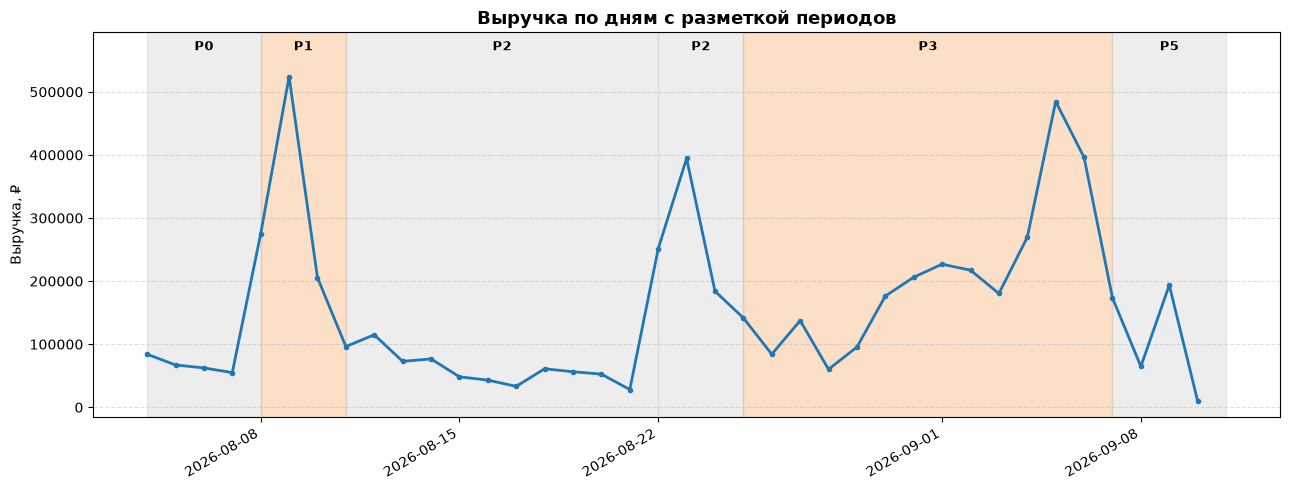

In [8]:
colors = {'факт': '#cccccc', 'гипотеза': '#f4a460', 'неизвестно': '#e57373'}

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(pd.to_datetime(daily_stats.index), daily_stats['revenue'], color='#1f77b4',
        linewidth=2, marker='o', markersize=3)

ymax = daily_stats['revenue'].max() * 1.08
for p in PERIODS:
    start = pd.to_datetime(p['start'])
    end = pd.to_datetime(p['end']) + pd.Timedelta(days=1)
    ax.axvspan(start, end, color=colors[p['confidence']], alpha=0.35)
    mid = start + (end - start) / 2
    ax.annotate(p['id'], xy=(mid, ymax), ha='center', fontsize=9, fontweight='bold')

ax.set_ylim(top=ymax * 1.05)
ax.set_title('Выручка по дням с разметкой периодов', fontsize=13, fontweight='bold')
ax.set_ylabel('Выручка, ₽')
ax.grid(axis='y', linestyle='--', alpha=0.4)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 6. Что двигало продажи внутри периодов

Для каждого периода с аномальным ростом (P1, P2, P3) считаем, какие курсы дали основной прирост относительно фона (среднее по P0+P2+P5).

In [9]:
baseline_dates = set()
for p in PERIODS:
    if p['confidence'] == 'факт':
        baseline_dates |= set(pd.date_range(p['start'], p['end']).date)
baseline_days = len(baseline_dates)
baseline_per_course = df[df['Дата'].isin(baseline_dates)].groupby('Курс').size() / baseline_days

lift_rows = []
for p in PERIODS:
    if p['confidence'] == 'факт':
        continue
    start, end = pd.to_datetime(p['start']).date(), pd.to_datetime(p['end']).date()
    days = (end - start).days + 1
    sub = df[(df['Дата'] >= start) & (df['Дата'] <= end)]
    per_course = sub.groupby('Курс').size() / days
    comp = pd.DataFrame({'период_шт_день': per_course, 'фон_шт_день': baseline_per_course}).fillna(0)
    comp = comp[comp['период_шт_день'] > 0]
    comp['прирост_шт_день'] = comp['период_шт_день'] - comp['фон_шт_день']
    top = comp.sort_values('прирост_шт_день', ascending=False).head(4)
    top.insert(0, 'период', p['id'])
    lift_rows.append(top.reset_index().rename(columns={'index': 'курс'}))

lift_df = pd.concat(lift_rows, ignore_index=True).round(2)
display(lift_df)

,Курс,период,период_шт_день,фон_шт_день,прирост_шт_день
0,Алгоритмы старт,P1,16.33,1.09,15.24
1,Аналитика старт,P1,11.67,1.18,10.48
2,ML старт,P1,11.00,1.23,9.77
3,Backend старт,P1,7.33,0.27,7.06
4,ML про,P3,4.77,1.18,3.59
5,Аналитика про,P3,4.46,1.36,3.10
6,AI агенты,P3,4.31,1.59,2.72
7,Backend про,P3,2.92,0.64,2.29


## 7. Кто покупает: LTV, retention, кросс-продажи

In [10]:
student_profile = df.groupby('Номер студента').agg(
    total_orders=('order_id', 'nunique'),
    total_courses=('Курс', 'count'),
    ltv=('Сумма', 'sum'),
).reset_index()

repeat_share = (student_profile['total_orders'] > 1).mean()
multi_course_share = (student_profile['total_courses'] > 1).mean()

print(f"Студентов: {len(student_profile)} | Средний LTV: {student_profile['ltv'].mean():,.0f} ₽ | "
      f"Медианный LTV: {student_profile['ltv'].median():,.0f} ₽")
print(f"С несколькими курсами (вкл. бандлы): {multi_course_share:.1%} | "
      f"Повторные заказы во времени: {repeat_share:.1%}")

student_courses = df.groupby('Номер студента')['Курс'].apply(list)
pairs = []
for courses in student_courses:
    for i in range(len(courses) - 1):
        if courses[i] != courses[i + 1]:
            pairs.append(tuple(sorted([courses[i], courses[i + 1]])))

top_pairs = pd.Series(pairs).value_counts().head(5).rename('количество').to_frame()
display(top_pairs)

Студентов: 606 | Средний LTV: 9,744 ₽ | Медианный LTV: 8,950 ₽
С несколькими курсами (вкл. бандлы): 26.9% | Повторные заказы во времени: 3.3%


,количество
"(Аналитика про, Аналитика старт)",25
"(ML старт, Алгоритмы старт)",24
"(AI агенты, ML про)",19
"(ML про, ML старт)",14
"(Алгоритмы про, Алгоритмы старт)",10


## 8. Что мы знаем / оцениваем / не можем узнать

**Знаем (факт из данных):**
- 795 строк → **627 заказов** (правило: разрыв больше часа = новый заказ) → **606 уникальных покупателей**, период 04.08–10.09.2026 (38 дней)
- Периоды роста продаж количественно выделяются относительно фактического фона; коэффициенты приведены в таблице выше, причинность не доказана
- около 25% заказов — пакеты, и минимум один пакет (`ML старт` + `Алгоритмы старт`) продавался ощутимо дешевле суммы отдельных цен — это реальная скидка, не совпадение
- Повторные покупки редки: 3.3% покупателей за 5.5 недель
- P1 состоит почти целиком из курсов линейки "Старт" → похоже на промо этой линейки, но точные условия акции не подтверждены источником
- P3 совпадает по времени и тематике со стажировкой в Т-Банк / launch PRO-курсов — правдоподобно, но не подтверждено ссылкой на реальный пост

**Оцениваем (гипотеза, не факт):**

- "Прирост" каждого периода — это разница факт-минус-фон, не причинно доказанный эффект (нет A/B/holdout)

**Пока узнать нельзя:**

- Настоящий причинный эффект акций (incrementality) — нужен эксперимент, а не пересчёт этой же таблицы

## 9. Итоговые рекомендации


**Продукт.** Связка `ML старт` + `Алгоритмы старт` — самый частый и при этом реально дисконтированный бандл; есть смысл сделать его постоянным предложением, а не разовой акцией.

**Retention.** Повторные покупки почти отсутствуют (3.3%) — выручка в основном одноразовая в рамках промо-окна. Стоит продумать триггерную цепочку (например, "Старт → Про" через несколько недель после первого курса).

**Измерения на будущее.** Ничего из выводов выше нельзя усилить без источника трафика — это прямой аргумент в пользу трекинг-слоя (deep links, Ad Registry), который мы спроектировали далее.

## 10. Measurement system: от продажи к маркетинговому касанию

На этом шаге соединяем EDA с основной задачей кейса. Исторический `base.xlsx` не содержит рекламного источника, поэтому attribution и ROMI нельзя честно восстановить постфактум. Вместо попытки «угадать» источник мы проектируем слой измерения, который начинает собирать его **до** следующего запуска.

### Что уже реализовано в MVP

По текущему MVP команды уже есть рабочие элементы measurement system:

- Telegram-бот/контур вокруг воронки;
- специальные tracking-ссылки для различения источников трафика;
- промокоды;
- административная панель для контроля кампаний и результатов.

Это позволяет строить цепочку:

`campaign → tracking link / promo code → Telegram user → lead → payment → revenue`

Важное ограничение: реализация MVP в этом ноутбуке не воспроизводится, потому что его исходный код/экспорт событий не приложен. Поэтому ниже описывается контракт данных и аналитический слой, который можно подключить к фактическому логу MVP.


### 10.1. Единая модель событий

Минимальная модель данных, которую стоит поддерживать в MVP:

| Сущность | Ключевые поля | Зачем |
|---|---|---|
| `campaign` | `campaign_id`, `campaign_name`, `channel`, `start_at`, `end_at` | кампания |
| `placement` | `placement_id`, `campaign_id`, `telegram_channel`, `publication_time`, `cost` | конкретное размещение |
| `creative` | `creative_id`, `creative_type`, `message_id` | креатив |
| `touch` | `touch_id`, `anon_user_id`, `placement_id`, `creative_id`, `timestamp`, `tracking_link_id` | маркетинговое касание |
| `lead` | `lead_id`, `anon_user_id`, `timestamp`, `source` | начало воронки |
| `payment` | `payment_id`, `anon_user_id`, `order_id`, `timestamp`, `amount` | факт оплаты |
| `order_item` | `order_id`, `course`, `amount` | состав заказа |
| `promo` | `promo_code`, `campaign_id`, `discount`, `valid_from`, `valid_to` | отдельный сигнал кампании |

Для каждого события должны быть известны минимум: **кто → что сделал → когда → откуда пришёл → к какой активности относится**. Внутри аналитики следует использовать обезличенный `anon_user_id`, а персональные данные держать вне аналитического слоя.


In [11]:
# Контракт события: пример структуры, которую должен выдавать MVP.
# Все идентификаторы здесь являются примерами; реальные значения должны приходить из MVP.

EVENT_COLUMNS = [
    'event_id', 'event_type', 'timestamp', 'anon_user_id',
    'campaign_id', 'placement_id', 'creative_id', 'tracking_link_id',
    'promo_code', 'lead_id', 'payment_id', 'order_id', 'amount'
]

# Пример единого DataFrame:
# events = pd.read_csv('mvp_events.csv', parse_dates=['timestamp'])
# missing = [c for c in EVENT_COLUMNS if c not in events.columns]
# assert not missing, f'MVP log missing columns: {missing}'
# events = events[EVENT_COLUMNS]

print('Ожидаемый контракт MVP:', ', '.join(EVENT_COLUMNS))


Ожидаемый контракт MVP: event_id, event_type, timestamp, anon_user_id, campaign_id, placement_id, creative_id, tracking_link_id, promo_code, lead_id, payment_id, order_id, amount


## 11. User stitching: как связать рекламу и покупку

Для следующего запуска предлагается **детерминированное связывание**, где это возможно:

1. `tracking_link_id` → уникальный переход/старт бота;
2. `promo_code` → дополнительный сигнал кампании;
3. `anon_user_id` → единый обезличенный идентификатор Telegram-пользователя;
4. `lead_id / order_id / payment_id` → связка лида с оплатой.

Если пользователь видел несколько рекламных размещений, сохраняются **все touchpoints**, а не только последний. Это принципиально: иначе потом нельзя посчитать multi-touch attribution.

Если deterministic stitching невозможен, пользователь не должен автоматически «приписываться» к кампании. Такой контакт маркируем как `unknown/organic` и отдельно показываем в отчётах.


## 12. Attribution engine

Исторически attribution сейчас не посчитать: в `base.xlsx` нет touchpoints и стоимости размещений. Поэтому ниже реализован воспроизводимый **аналитический движок**, который можно запускать поверх лога MVP.

Он поддерживает несколько правил из ТЗ: first touch, last touch, linear, time decay и position based.

Для каждой покупки распределяем `revenue` между всеми touchpoints пользователя внутри заданного attribution window. Это **не causal effect**: результат показывает, кому модель приписала уже случившуюся выручку.


In [12]:
from IPython.display import display

import numpy as np
import pandas as pd


def attribution_weights(n, method='linear', decay=0.5):
    """Возвращает веса длины n, сумма весов = 1."""
    if n <= 0:
        return np.array([])
    if method == 'first_touch':
        w = np.zeros(n); w[0] = 1
    elif method == 'last_touch':
        w = np.zeros(n); w[-1] = 1
    elif method == 'linear':
        w = np.ones(n)
    elif method == 'time_decay':
        # Последнему touch присваивается вес 1, предыдущим - decay^distance.
        w = np.array([decay ** (n - 1 - i) for i in range(n)], dtype=float)
    elif method == 'position_based':
        if n == 1:
            w = np.array([1.0])
        elif n == 2:
            w = np.array([0.5, 0.5])
        else:
            w = np.array([0.4] + [0.2 / (n - 2)] * (n - 2) + [0.4])
    else:
        raise ValueError(f'Unknown attribution method: {method}')
    return w / w.sum()


def attribute_orders(touches, orders, method='linear', window_days=7, decay=0.5):
    """
    touches: user_id, touch_time, channel/campaign
    orders: user_id, order_id, order_time, revenue
    """
    t = touches.copy()
    o = orders.copy()
    t['touch_time'] = pd.to_datetime(t['touch_time'])
    o['order_time'] = pd.to_datetime(o['order_time'])

    rows = []
    for row in o.itertuples(index=False):
        lo = row.order_time - pd.Timedelta(days=window_days)
        ts = t[(t['user_id'] == row.user_id) &
               (t['touch_time'] <= row.order_time) &
               (t['touch_time'] >= lo)].sort_values('touch_time')
        if ts.empty:
            rows.append({
                'order_id': row.order_id,
                'user_id': row.user_id,
                'campaign_id': 'unknown/organic',
                'attributed_revenue': row.revenue,
                'touch_count': 0,
            })
            continue

        weights = attribution_weights(len(ts), method=method, decay=decay)
        for (_, touch), weight in zip(ts.iterrows(), weights):
            rows.append({
                'order_id': row.order_id,
                'user_id': row.user_id,
                'campaign_id': touch['campaign_id'],
                'attributed_revenue': row.revenue * weight,
                'touch_count': len(ts),
            })
    return pd.DataFrame(rows)


# Synthetic demo: это не данные бизнеса.
syn_touches = pd.DataFrame({
    'user_id': ['u1','u1','u1','u2','u2'],
    'touch_time': pd.to_datetime(['2026-09-01','2026-09-03','2026-09-04','2026-09-02','2026-09-05']),
    'campaign_id': ['tg_A','own_channel','promo_B','tg_C','own_channel'],
})
syn_orders = pd.DataFrame({
    'user_id': ['u1','u2'],
    'order_id': ['o1','o2'],
    'order_time': pd.to_datetime(['2026-09-05','2026-09-06']),
    'revenue': [10000, 8000],
})

demo_attr = attribute_orders(syn_touches, syn_orders, method='linear', window_days=7)
display(demo_attr)
print('Demo выше - synthetic, не использовать как фактическую метрику кейса.')


,order_id,user_id,campaign_id,attributed_revenue,touch_count
0,o1,u1,tg_A,3333.333333,3
1,o1,u1,own_channel,3333.333333,3
2,o1,u1,promo_B,3333.333333,3
3,o2,u2,tg_C,4000.000000,2
4,o2,u2,own_channel,4000.000000,2


Demo выше - synthetic, не использовать как фактическую метрику кейса.


## 13. ROMI: attribution и incrementality разделяем

По ТЗ полезно держать две метрики отдельно:

**Attributed ROMI**

`ROMI_attr = (Attributed Revenue - Marketing Cost) / Marketing Cost`

Это управленческая метрика attribution-модели.

**Incremental ROMI**

`ROMI_inc = (Incremental Profit - Marketing Cost) / Marketing Cost`

Это оценка реального дополнительного эффекта рекламы.

Сейчас исторический `Marketing Cost` отсутствует, поэтому числовой ROMI по прошлым кампаниям нельзя честно восстановить. В MVP нужно обязательно логировать `cost` на уровне **placement**, иначе вопрос «куда направить следующие 300 000 ₽» останется без экономической основы.


In [13]:
def calculate_romi(attributed_revenue, marketing_cost):
    if marketing_cost <= 0:
        raise ValueError('marketing_cost must be > 0')
    return (attributed_revenue - marketing_cost) / marketing_cost

# Synthetic example only.
example_revenue = 180_000
example_cost = 60_000
print(f'Synthetic ROMI_attr = {calculate_romi(example_revenue, example_cost):.2f}')
print('Для production-расчёта сюда должны поступать реальные attributed_revenue и placement cost из MVP.')


Synthetic ROMI_attr = 2.00
Для production-расчёта сюда должны поступать реальные attributed_revenue и placement cost из MVP.


## 14. Incrementality: как доказать, что реклама действительно добавляет продажи

Attribution отвечает на вопрос **«кому приписать продажу?»**, а incrementality - **«произошла бы она без рекламы?»**.

Для MVP/следующего запуска наиболее практичный дизайн:

- randomized holdout / audience split, где часть сопоставимой аудитории не получает конкретную рекламную коммуникацию;
- заранее фиксируем primary metric: revenue / orders / contribution margin;
- фиксируем окно измерения;
- сравниваем treatment и control;
- строим доверительный интервал эффекта.

При наличии агрегированных временных рядов можно дополнительно рассматривать interrupted time series или DiD, но для маркетингового решения предпочтительнее рандомизированный holdout, если его можно операционно реализовать.


In [14]:
# Шаблон расчёта uplift для будущего эксперимента.
def incremental_uplift(treatment_revenue, treatment_users, control_revenue, control_users):
    tr = treatment_revenue / treatment_users
    cr = control_revenue / control_users
    return tr - cr, tr / cr - 1

# Synthetic numbers only:
uplift_abs, uplift_rel = incremental_uplift(120_000, 100, 90_000, 100)
print(f'Synthetic uplift: {uplift_abs:,.0f} ₽ на пользователя, {uplift_rel:.1%}')
print('Это шаблон методики, а не оценка реального эффекта рекламы.')


Synthetic uplift: 300 ₽ на пользователя, 33.3%
Это шаблон методики, а не оценка реального эффекта рекламы.


## 15. Forecast: честный baseline важнее сложной модели

История короткая - 38 дней. Поэтому здесь разумный baseline: **naive / moving average**, а качество проверять backtest по времени.

Для forecasting в production будущими признаками должны стать `ad_spend`, `placements`, `sale_post`, `discount`, `launch`, `channel`, `creative` и связанные маркетинговые события. Пока этих признаков исторически нет, модель не должна делать вид, что она умеет предсказывать эффект рекламы.


In [15]:
# Forecast baseline поверх уже рассчитанного daily_stats.
# Код рассчитан на объект daily_stats из предыдущих секций ноутбука.

def backtest_daily_revenue(series, min_train=14, horizon=1):
    s = pd.Series(series).astype(float).reset_index(drop=True)
    rows = []
    for i in range(min_train, len(s) - horizon + 1):
        train = s.iloc[:i]
        actual = s.iloc[i:i+horizon].sum()
        pred = train.tail(7).mean()
        rows.append({'date_idx': i, 'actual': actual, 'pred': pred})
    bt = pd.DataFrame(rows)
    bt['abs_error'] = (bt['actual'] - bt['pred']).abs()
    return bt

try:
    forecast_bt = backtest_daily_revenue(daily_stats['revenue'])
    print(f'MAE 7-day-moving-average baseline: {forecast_bt["abs_error"].mean():,.0f} ₽')
    display(forecast_bt.tail())
except NameError:
    print('Запустите предыдущие секции ноутбука, чтобы использовать daily_stats.')


MAE 7-day-moving-average baseline: 99,496 ₽


,date_idx,actual,pred,abs_error
19,33,396075.0,251622.428571,144452.571429
20,34,173375.0,283013.142857,109638.142857
21,35,64750.0,278325.571429,213575.571429
22,36,193600.0,255164.142857,61564.142857
23,37,9950.0,251781.285714,241831.285714


## 16. Как принимать решение по бюджету 300 000 ₽

После накопления данных решение должно строиться не по «самому большому revenue», а примерно так:

`placement → cost → touches → orders → attributed revenue → incremental effect → contribution margin → marginal ROI`

Практический цикл:

1. Запустить несколько каналов/размещений с уникальными `placement_id` и сопоставимыми креативами.
2. Собирать все touchpoints и стоимость каждого placement.
3. Для каждого канала считать attribution как диагностическую метрику.
4. Для части кампаний проводить holdout и оценивать incremental lift.
5. Перераспределять бюджет в пользу каналов с устойчивым incremental ROI, а не просто высоким объёмом продаж.
6. Оставлять отдельную долю бюджета на новые тесты, чтобы не оптимизировать систему только под уже известные каналы.

Такой подход превращает ответ руководителю из «купите рекламу в канале X» в воспроизводимую систему распределения бюджета.


## 17. Финальная граница знания

### Знаем

- фактические продажи, заказы по принятому правилу, покупателей и структуру покупок;
- временные всплески и продуктовые сочетания в доступном периоде;
- что исторического marketing source layer в `base.xlsx` нет.

### Оцениваем

- влияние отдельных периодов относительно baseline;
- будущую attribution-оценку после подключения touchpoints;
- прогноз продаж через backtest baseline.

### Пока не можем узнать

- точный исторический ROMI по placement;
- causal effect каждой рекламы;
- реальную incremental revenue без контрольного дизайна;
- достоверный CAC по историческим кампаниям при отсутствии их стоимости.

Это не недостаток аналитики - это свойства исходной наблюдаемости. Именно поэтому основной результат решения должен быть не только EDA, но и рабочая система сбора недостающих событий.


## 18. Что показать в презентации

**1. Проблема.** Сейчас продажи видны, путь к ним - нет.

**2. EDA.** 795 строк, 606 покупателей, 627 заказов по принятому правилу; бандлы и повторные покупки; всплески продаж.

**3. Ограничение.** Исторического source/cost layer нет, поэтому честный historical ROMI невозможен.

**4. MVP.** Telegram tracking + уникальные ссылки + промокоды + admin panel.

**5. Архитектура.** `campaign → placement → touch → lead → payment → revenue`.

**6. Attribution.** Multi-touch engine с несколькими правилами и явным attribution window.

**7. Incrementality.** Holdout/experimental design.

**8. ROMI.** `ROMI_attr` и `ROMI_inc` отдельно.

**9. Forecast.** Baseline + backtest; маркетинговые признаки - для следующей итерации.

**10. Бюджет.** Сначала измерить incremental effect, затем перераспределять деньги.
